In [9]:
# Imports 
import os
from pathlib import Path 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import cv2
from collections import Counter 
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import shutil
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestNeighbors

from PIL import Image
import json
import sys
import src

In [10]:
PROJECT_ROOT = Path.cwd().parent

# Make absolutely sure Python can find the project root.
sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:")
print(Path.cwd())

print("\nProject root:")
print(PROJECT_ROOT)

print("\nChecking src folder:")
print(PROJECT_ROOT / "src")
print("Exists:", (PROJECT_ROOT / "src").is_dir())

print("\nPython import path:")
print(sys.path[0])

Current working directory:
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/notebooks

Project root:
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection

Checking src folder:
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/src
Exists: True

Python import path:
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection


In [11]:
# Project Paths
PROJECT_ROOT = Path("/home/priyanshu-sharma/Documents/industrial-surface-defect-detection")
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "NEU-DET"

TRAIN_IMAGES = DATA_DIR / "train" / "images"
TRAIN_ANNOTATIONS = DATA_DIR / "train" / "annotations"

VAL_IMAGES = DATA_DIR / "validation" / "images"
VAL_ANNOTATIONS = DATA_DIR / "validation" / "annotations"

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_DIR)
print("Train images:", TRAIN_IMAGES)
print("Validation images:", VAL_IMAGES)

Project root: /home/priyanshu-sharma/Documents/industrial-surface-defect-detection
Dataset: /home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET
Train images: /home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET/train/images
Validation images: /home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET/validation/images


In [12]:
# Verifying dataset 
train_images = list(TRAIN_IMAGES.glob("*"))
val_images = list(VAL_IMAGES.glob("*"))

print("Training files:", len(train_images))
print("Validation files:", len(val_images))

print("\nFirst 5 training files:")
for file in train_images[:5]:
    print(file.name)

Training files: 6
Validation files: 6

First 5 training files:
crazing
pitted_surface
patches
scratches
rolled-in_scale


In [13]:
# Inspect image files recursively

image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

train_images = [
    file for file in TRAIN_IMAGES.rglob("*")
    if file.is_file() and file.suffix.lower() in image_extensions
]

val_images = [
    file for file in VAL_IMAGES.rglob("*")
    if file.is_file() and file.suffix.lower() in image_extensions
]

print(f"Training images: {len(train_images)}")
print(f"Validation images: {len(val_images)}")

print("\nFirst 10 training images:")
for file in train_images[:10]:
    print(file)

Training images: 1440
Validation images: 360

First 10 training images:
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET/train/images/crazing/crazing_105.jpg
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET/train/images/crazing/crazing_159.jpg
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET/train/images/crazing/crazing_186.jpg
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET/train/images/crazing/crazing_236.jpg
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET/train/images/crazing/crazing_122.jpg
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET/train/images/crazing/crazing_20.jpg
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET/train/images/crazing/crazing_48.jpg
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/

In [14]:
# Inspect a sample image 

sample_path = train_images[0]
image = cv2.imread(str(sample_path))

print("Image file:", sample_path.name)
print("Image path:", sample_path)
print("Image shape:", image.shape)
print("Image data type:", image.dtype)
print("Maximum pixel value:", image.max())
print("Minimum pixel value:", image.min())

Image file: crazing_105.jpg
Image path: /home/priyanshu-sharma/Documents/industrial-surface-defect-detection/data/raw/NEU-DET/train/images/crazing/crazing_105.jpg
Image shape: (200, 200, 3)
Image data type: uint8
Maximum pixel value: 237
Minimum pixel value: 44


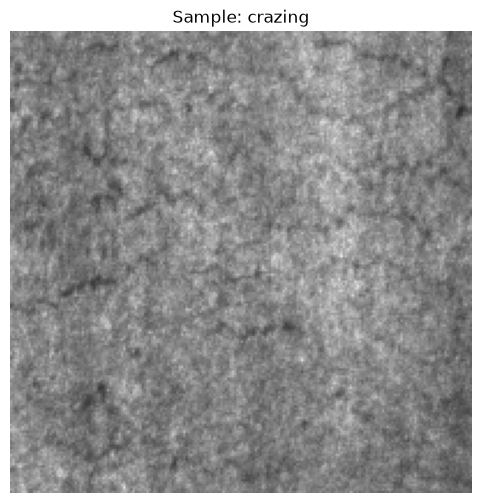

In [15]:
# Visualize the image

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title(f"Sample: {sample_path.parent.name}")
plt.axis("off")
plt.show()

In [16]:
# Inspect an XML annotation
import xml.etree.ElementTree as ET

annotation_files = list(TRAIN_ANNOTATIONS.glob("*.xml"))
print("Annotation files:", len(annotation_files))

sample_annotation = annotation_files[0]
print("\n Sample annotation file:")
print(sample_annotation.name)

# Parse the XML file
tree = ET.parse(sample_annotation)
root = tree.getroot()

print("\nXML structure:")
for child in root:
    print(child.tag)

Annotation files: 1439

 Sample annotation file:
rolled-in_scale_231.xml

XML structure:
folder
filename
source
size
segmented
object
object
object


In [17]:
# Extracting defect information and bounding box
for obj in root.findall("object"):
    # Defect class name 
    name = obj.find("name").text
    # Bounding box
    bbox = obj.find("bndbox")

    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    print("Defect class:", name)
    print("Bounding box:")
    print(f"xmin = {xmin}")
    print(f"ymin = {ymin}")
    print(f"xmax = {xmax}")
    print(f"ymax = {ymax}")

Defect class: rolled-in_scale
Bounding box:
xmin = 1
ymin = 1
xmax = 57
ymax = 37
Defect class: rolled-in_scale
Bounding box:
xmin = 1
ymin = 94
xmax = 66
ymax = 178
Defect class: rolled-in_scale
Bounding box:
xmin = 109
ymin = 117
xmax = 161
ymax = 196


In [18]:
# Discover all defect classes

defect_classes = set()

for annotation_file in TRAIN_ANNOTATIONS.glob("*.xml"):
    tree = ET.parse(annotation_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name").text
        defect_classes.add(name)

print("Defect classes found:")
for class_name in sorted(defect_classes):
    print("-", class_name)
print("\nTotal defect classes:", len(defect_classes))

Defect classes found:
- crazing
- inclusion
- patches
- pitted_surface
- rolled-in_scale
- scratches

Total defect classes: 6


In [19]:
# Count samples in each defect class

class_counts = Counter()
for annotation_file in TRAIN_ANNOTATIONS.glob("*.xml"):
    tree = ET.parse(annotation_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name").text
        class_counts[name] += 1

print("Class distribution:\n") 
for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count}")       

Class distribution:

crazing: 524
inclusion: 852
patches: 688
pitted_surface: 345
rolled-in_scale: 496
scratches: 427


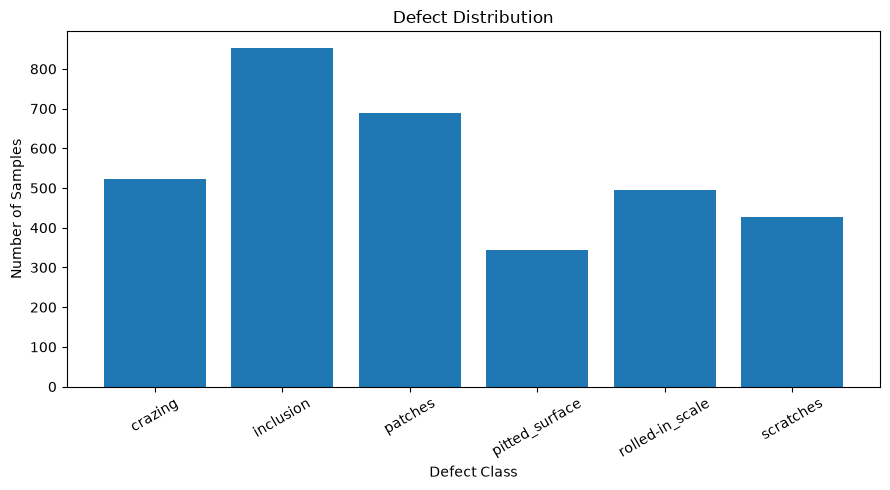

In [20]:
# Visualize class distribution

classes = sorted(class_counts.keys())
counts = [class_counts[class_name] for class_name in classes]

plt.figure(figsize=(9, 5))

plt.bar(classes, counts)
plt.title("Defect Distribution")
plt.xlabel("Defect Class")
plt.ylabel("Number of Samples")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [21]:
# Visualize one image from each defect class

import random 
# Get all defect class folders
class_folders = sorted([
    folder for folder in TRAIN_IMAGES.iterdir()
    if folder.is_dir()
])
print("Classes found:")
for folder in class_folders:
    print("-", folder.name)

Classes found:
- crazing
- inclusion
- patches
- pitted_surface
- rolled-in_scale
- scratches


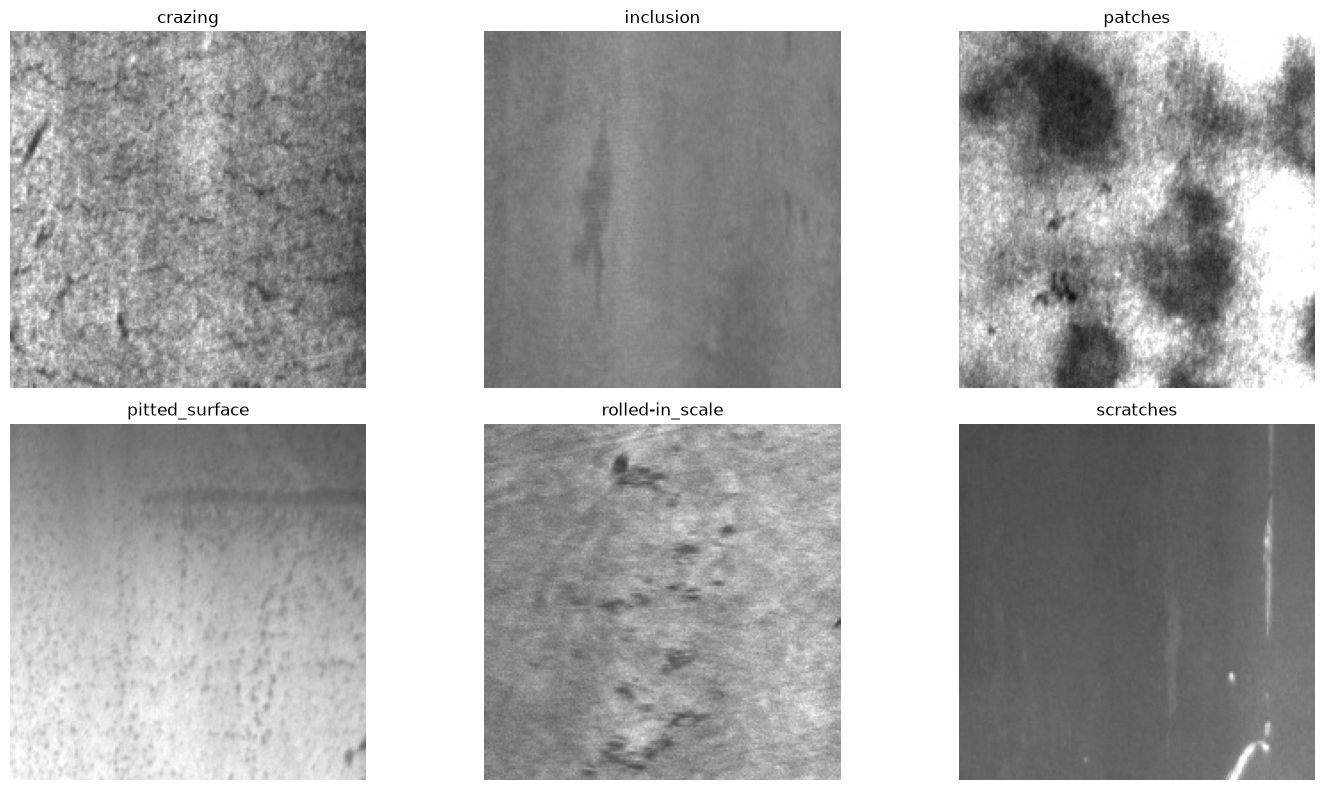

In [22]:
# Display one sample from each class
plt.figure(figsize=(15, 8))
for i, class_folder in enumerate(class_folders):
    # Find images inside this class folder
    images = [
        file for file in class_folder.iterdir()
        if file.is_file() and file.suffix.lower() in image_extensions
    ]
    # Pick one random image 
    sample = random.choice(images)

    # Read image
    img = cv2.imread(str(sample))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_rgb, cmap="gray")
    plt.title(class_folder.name)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [23]:
# Check image dimensions
image_shapes = Counter()

for image_path in train_images:
    img = cv2.imread(str(image_path))
    if img is not None:
        image_shapes[img.shape] += 1

print("Image shape distribution:\n")
for shape, count in image_shapes.items():
    print(f"{shape}: {count} images")

Image shape distribution:

(200, 200, 3): 1440 images


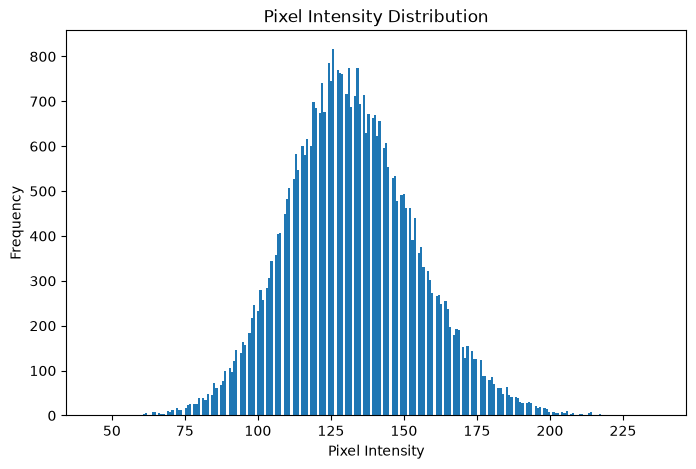

In [24]:
# Inspect pixel intensity distribution
sample_image = cv2.imread(str(train_images[0]), cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(8, 5))
plt.hist(sample_image.ravel(), bins=256)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [25]:
# Image Transformations 
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
print("Traning transformations created.")
print("Validation transformations created.")

Traning transformations created.
Validation transformations created.


In [26]:
# Creating Pytorch datasets
train_dataset = datasets.ImageFolder(
    root=str(TRAIN_IMAGES),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=str(VAL_IMAGES),
    transform=val_transform
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

print("\nClass names:")
print(train_dataset.classes)

print("\nClass to index mapping:")
print(train_dataset.class_to_idx)

Training samples: 1440
Validation samples: 360

Class names:
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']

Class to index mapping:
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [27]:
# Create Dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Batch size: 32
Training batches: 45
Validation batches: 12


In [28]:
# Inspect a batch 
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image tensor dtype:", images.dtype)
print("Labels:", labels)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image tensor dtype: torch.float32
Labels: tensor([4, 3, 2, 0, 2, 4, 5, 3, 2, 1, 4, 5, 2, 0, 2, 3, 5, 1, 0, 1, 1, 3, 4, 5,
        1, 1, 0, 1, 2, 1, 1, 0])


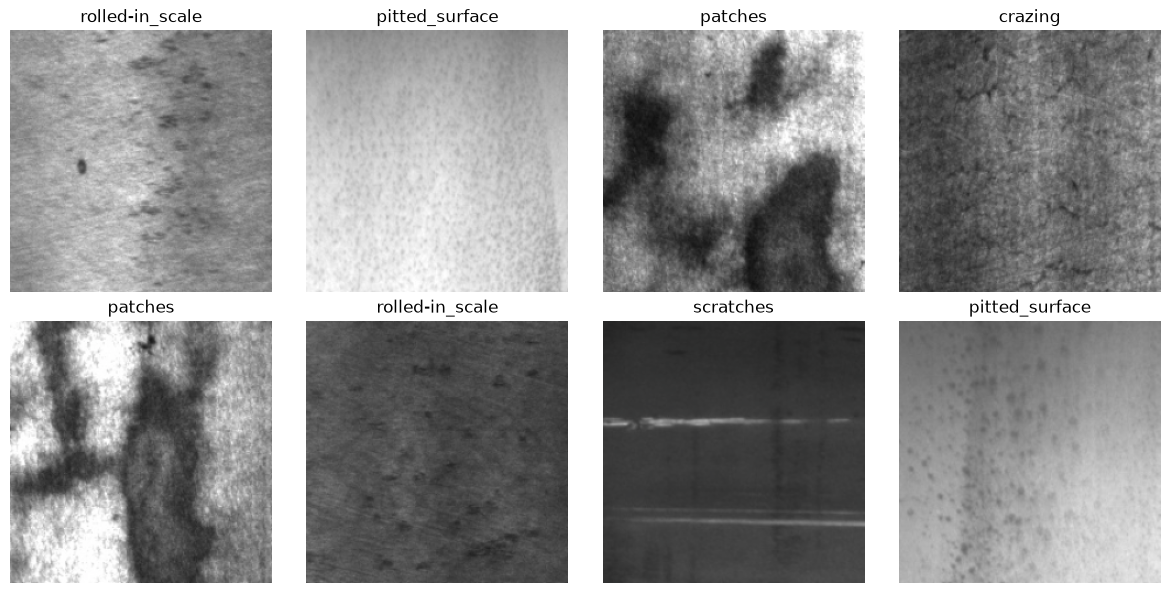

In [29]:
# Visualize transformed image
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    # Undo normalization for visualization 
    img = images[i].clone()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [30]:
# Load pretrained ResNet18
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [31]:
# Inspect the final classification layer 
print("Original classifier:")
print(model.fc)

Original classifier:
Linear(in_features=512, out_features=1000, bias=True)


In [32]:
# Adapt ResNet18 to our six defect classes
num_classes = len(train_dataset.classes)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)
print("Updated classifier:")
print(model.fc)

Updated classifier:
Linear(in_features=512, out_features=6, bias=True)


In [33]:
# Freeze the pretrained layers 
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the new classifier
for param in model.fc.parameters():
    param.requires_grad = True

print("Trainable parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable parameters:
fc.weight
fc.bias


In [34]:
# Select Training Device 
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)
model = model.to(device)

Using device: cpu


In [35]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)
print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [36]:
# Count parameters
total_parameters = sum(
    param.numel()
    for param in model.parameters()
)

trainable_parameters = sum(
    param.numel()
    for param in model.parameters()
    if param.requires_grad
)

print(f"Total parameteres: {total_parameters:,}")
print(f"Trainable paramters: {trainable_parameters:,}")

Total parameteres: 11,179,590
Trainable paramters: 3,078


In [37]:
# Training configuration 
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

print("Number of epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)

Number of epochs: 10
Learning rate: 0.001


In [38]:
# Training Function
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        # Move data to the selected device
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update trainable weights
        optimizer.step()

        # Track statistics
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / total 
    epoch_accuracy = correct / total 

    return epoch_loss, epoch_accuracy


In [39]:
# Validation function 
def validate(model, dataloader, criterion, device):
    
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Track statistics
            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [40]:
# Train the model 
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model, 
        val_loader, 
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch + 1} / {NUM_EPOCHS}]"
        f"Train loss: {train_loss:.4f}"
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f}"
    )

    # Save the best model 
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(
            model.state_dict(),
            PROJECT_ROOT / "models" / "best_model.pth"
        )
        print("Best model saved!")

Epoch [1 / 10]Train loss: 0.9095| Train Acc: 0.7674 | Val Loss: 0.8286 | Val Acc: 0.7583
Best model saved!
Epoch [2 / 10]Train loss: 0.2999| Train Acc: 0.9500 | Val Loss: 0.2701 | Val Acc: 0.9694
Best model saved!
Epoch [3 / 10]Train loss: 0.1779| Train Acc: 0.9812 | Val Loss: 0.2167 | Val Acc: 0.9611
Epoch [4 / 10]Train loss: 0.1423| Train Acc: 0.9806 | Val Loss: 0.1651 | Val Acc: 0.9750
Best model saved!
Epoch [5 / 10]Train loss: 0.1143| Train Acc: 0.9806 | Val Loss: 0.1339 | Val Acc: 0.9750
Epoch [6 / 10]Train loss: 0.1141| Train Acc: 0.9764 | Val Loss: 0.1466 | Val Acc: 0.9556
Epoch [7 / 10]Train loss: 0.0841| Train Acc: 0.9840 | Val Loss: 0.1145 | Val Acc: 0.9722
Epoch [8 / 10]Train loss: 0.0876| Train Acc: 0.9792 | Val Loss: 0.0959 | Val Acc: 0.9806
Best model saved!
Epoch [9 / 10]Train loss: 0.0786| Train Acc: 0.9833 | Val Loss: 0.0920 | Val Acc: 0.9750
Epoch [10 / 10]Train loss: 0.0611| Train Acc: 0.9854 | Val Loss: 0.0901 | Val Acc: 0.9833
Best model saved!


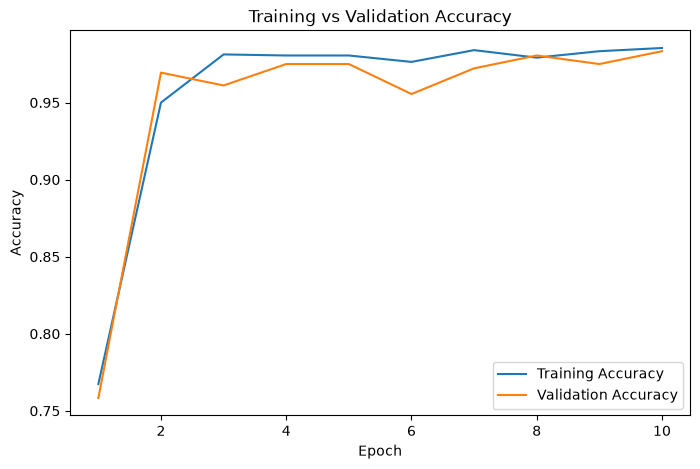

In [41]:
# Plot training and validation metrics 
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracies, label ="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

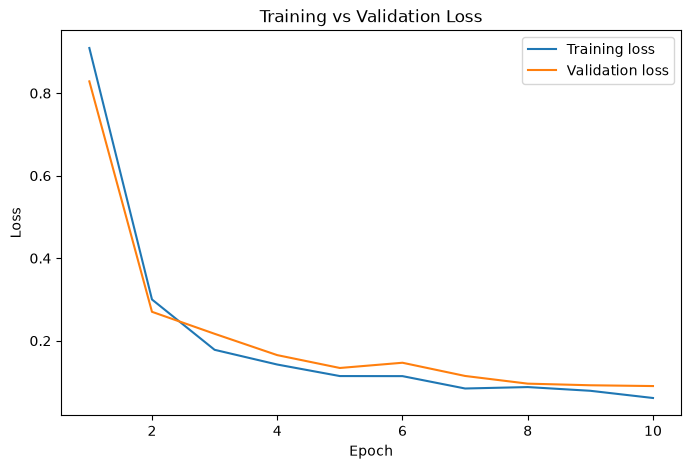

In [42]:
# Plot training and validation time
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, label="Training loss")
plt.plot(epochs, val_losses, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [43]:
# Load the best model 

best_model_path = PROJECT_ROOT / "models" / "best_model.pth"

model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model = model.to(device)
model.eval()

print("Best model loaded!")
print("Model path:", best_model_path)
print("Best validation accuracy:", f"{best_val_accuracy:.4f}")

Best model loaded!
Model path: /home/priyanshu-sharma/Documents/industrial-surface-defect-detection/models/best_model.pth
Best validation accuracy: 0.9833


In [44]:
# Generate predictions on the validation set 
all_labels = []
all_predictions = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)

        predictions = outputs.argmax(dim=1)
        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

print("Total validation samples:", len(all_labels))
print("Total predictions:", len(all_predictions))

Total validation samples: 360
Total predictions: 360


In [45]:
# Classification report 

class_names = train_dataset.classes

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4
)
print(report)

                 precision    recall  f1-score   support

        crazing     1.0000    1.0000    1.0000        60
      inclusion     1.0000    0.9000    0.9474        60
        patches     1.0000    1.0000    1.0000        60
 pitted_surface     0.9677    1.0000    0.9836        60
rolled-in_scale     1.0000    1.0000    1.0000        60
      scratches     0.9375    1.0000    0.9677        60

       accuracy                         0.9833       360
      macro avg     0.9842    0.9833    0.9831       360
   weighted avg     0.9842    0.9833    0.9831       360



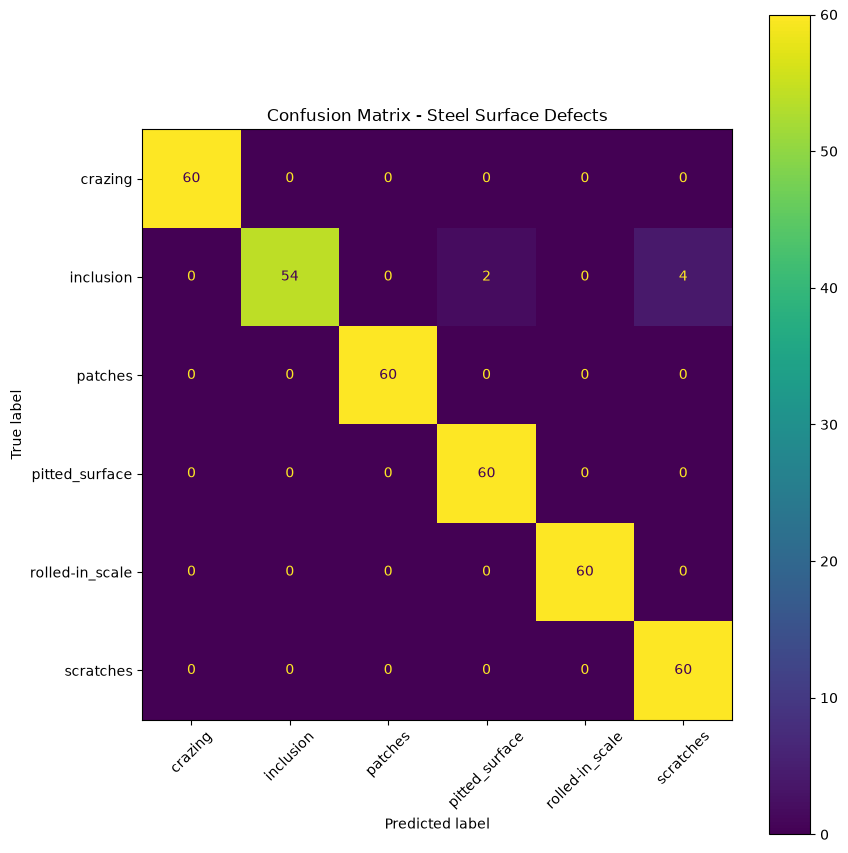

In [46]:
# Confusion Matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(9, 9))

disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("Confusion Matrix - Steel Surface Defects")
plt.tight_layout()
plt.show()

In [47]:
# Overall validation accuracy
accuracy = accuracy_score(
    all_labels,
    all_predictions
)
print(f"Validation Accuracy: {accuracy:.4%}")

Validation Accuracy: 98.3333%


In [48]:
# Find misclassified images 
misclassified = []

for image_path in val_images:
    # Get the true class from the parent folder 
    true_class = image_path.parent.name

    # get the class index
    true_index = class_names.index(true_class)

    # Load image
    img = cv2.imread(str(image_path))

    # Convert to PIL because our transforms expect PIL images
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pil_image = Image.fromarray(img_rgb)

    # Apply validation transform
    tensor = val_transform(pil_image).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(tensor)

    predicted_index = output.argmax(dim=1).item()

    if predicted_index != true_index:
        misclassified.append({
            "path": image_path,
            "actual": true_class,
            "predicted": class_names[predicted_index]
        })
print("Number of misclassified images:", len(misclassified))

Number of misclassified images: 6


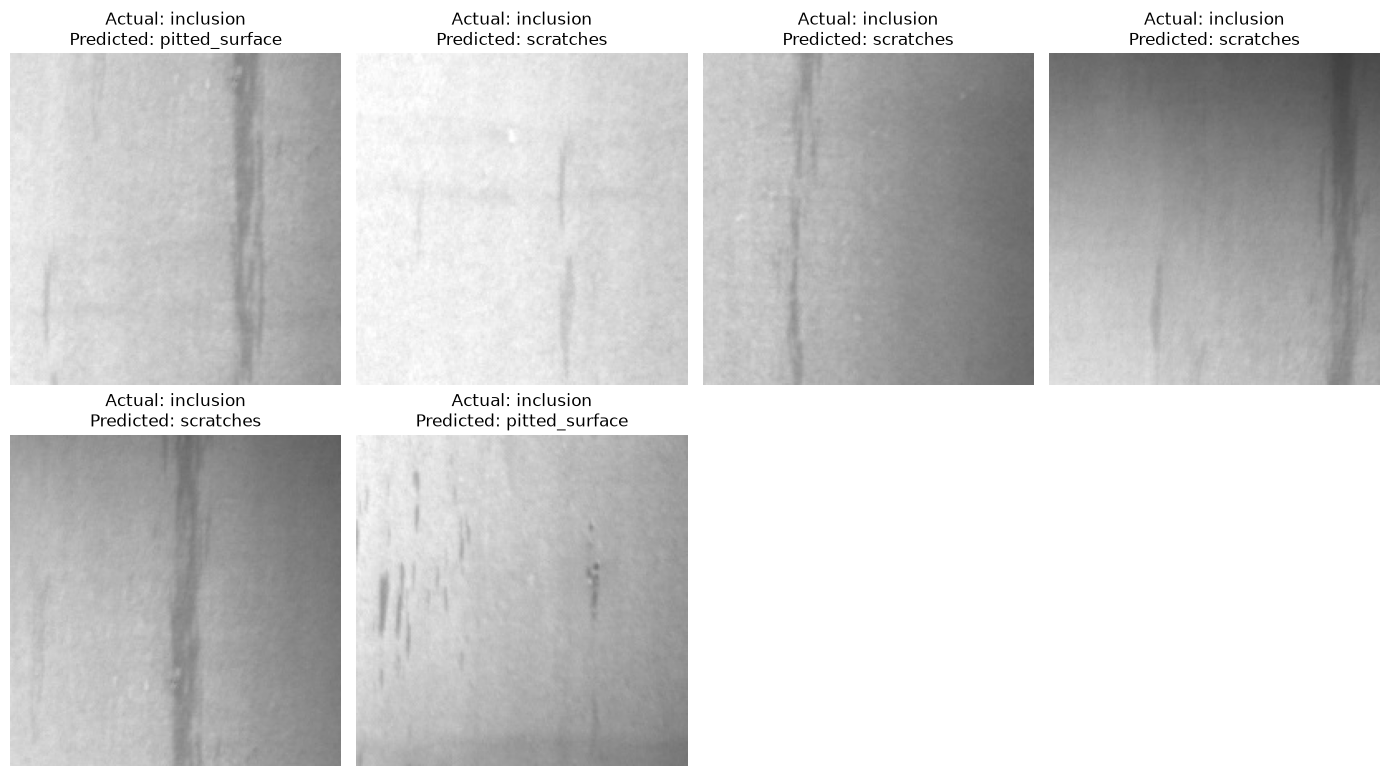

In [49]:
# Visualize Misclassified examples
num_examples = min(8, len(misclassified))

plt.figure(figsize=(14, 8))

for i in range(num_examples):
    item = misclassified[i]

    img = cv2.imread(str(item["path"]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img_rgb)

    plt.title(
        f"Actual: {item['actual']}\n"
        f"Predicted: {item['predicted']}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [50]:
# Reusable prediction function 

def predict_image(image_path, model, transform, class_names, device):

    # Load image
    image = cv2.imread(str(image_path))

    if image is None:
        raise ValueError(f"Could not load image: {image_path}")

    # OpenCV BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert numpy array to PIL image
    image = Image.fromarray(image)

    # Apply the same preprocessing used during validation 
    image_tensor = transform(image)

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Inference
    model.eval()

    with torch.no_grad():
        outputs = model(image_tensor)

        # Convert logits to probabilities 
        probabilities = torch.softmax(outputs, dim=1)

        # Get highest probability 
        confidence, predicted_index = torch.max(
            probabilities, dim=1
        )

    predicted_class = class_names[predicted_index.item()]
    confidence = confidence.item()
    return predicted_class, confidence, probabilities.cpu().numpy()[0]

In [51]:
# Test inference on the image

test_image = val_images[0]

predicted_class, confidence, probabilities = predict_image(
    test_image,
    model,
    val_transform,
    class_names,
    device
)

print("Image:", test_image.name)
print("Actual class:", test_image.parent.name)
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2%}")

Image: crazing_299.jpg
Actual class: crazing
Predicted class: crazing
Confidence: 99.92%


In [52]:
# Display probability for every class
probability_table = pd.DataFrame({
    "Defect": class_names,
    "Probability": probabilities
})

probability_table = probability_table.sort_values(
    "Probability",
    ascending=False
)

probability_table["Probability"] = (
    probability_table["Probability"] * 100
)

print(probability_table.to_string(index=False))

         Defect  Probability
        crazing    99.917480
 pitted_surface     0.042173
        patches     0.016432
rolled-in_scale     0.012010
      inclusion     0.007558
      scratches     0.004334


In [53]:
# Create inspection status
def get_inspection_status(confidence, threshold=0.70):
    if confidence >= threshold:
        return "DEFECT CLASSIFIED"

    return "LOW CONFIDENCE - MANUAL INSPECTION"

status = get_inspection_status(confidence)
print("Inspection status:", status)

Inspection status: DEFECT CLASSIFIED


In [54]:
# Save model metadata
metadata = {
    "model_name": "ResNet18",
    "num_classes": len(class_names),
    "class_names": class_names,
    "image_size": [224, 224],
    "confidence_threshold": 0.70
}

metadata_path = PROJECT_ROOT / "models" / "metadata.json"

with open(metadata_path, "w") as file:
    json.dump(metadata, file, indent=4)

print("Metadata saved to:")
print(metadata_path)

Metadata saved to:
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/models/metadata.json


In [55]:
# Verify saved artifacts
print("Model exists:", best_model_path.exists())
print("Metadata exists:", metadata_path.exists())

with open(metadata_path, "r") as file:
    loaded_metadata = json.load(file)

print("\nLoaded metadata:")
print(json.dumps(loaded_metadata, indent=4))

Model exists: True
Metadata exists: True

Loaded metadata:
{
    "model_name": "ResNet18",
    "num_classes": 6,
    "class_names": [
        "crazing",
        "inclusion",
        "patches",
        "pitted_surface",
        "rolled-in_scale",
        "scratches"
    ],
    "image_size": [
        224,
        224
    ],
    "confidence_threshold": 0.7
}


In [56]:
# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ------------------------------------------------------------
# Domain dataset paths
# ------------------------------------------------------------

DOMAIN_DIR = PROJECT_ROOT / "data" / "domain"

DOMAIN_TRAIN_DIR = DOMAIN_DIR / "train"
DOMAIN_VAL_DIR = DOMAIN_DIR / "validation"

STEEL_TRAIN_DIR = DOMAIN_TRAIN_DIR / "steel"
NON_STEEL_TRAIN_DIR = DOMAIN_TRAIN_DIR / "non_steel"

STEEL_VAL_DIR = DOMAIN_VAL_DIR / "steel"
NON_STEEL_VAL_DIR = DOMAIN_VAL_DIR / "non_steel"


# ------------------------------------------------------------
# Create folders
# ------------------------------------------------------------

for directory in [
    STEEL_TRAIN_DIR,
    NON_STEEL_TRAIN_DIR,
    STEEL_VAL_DIR,
    NON_STEEL_VAL_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Helper: find image files recursively
# ------------------------------------------------------------

def get_image_files(folder):

    valid_extensions = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp"
    }

    return sorted(
        path
        for path in folder.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower()
            in valid_extensions
        )
    )


# ------------------------------------------------------------
# Find existing steel images
# ------------------------------------------------------------

steel_train_source = get_image_files(
    TRAIN_IMAGES
)

steel_val_source = get_image_files(
    VAL_IMAGES
)


print(
    "Steel training images:",
    len(steel_train_source)
)

print(
    "Steel validation images:",
    len(steel_val_source)
)

Steel training images: 1440
Steel validation images: 360


In [57]:

# ------------------------------------------------------------
# Copy training steel images
# ------------------------------------------------------------

for i, image_path in enumerate(
    steel_train_source
):

    destination = (
        STEEL_TRAIN_DIR
        / f"steel_train_{i:04d}.jpg"
    )

    if not destination.exists():

        shutil.copy2(
            image_path,
            destination
        )


# ------------------------------------------------------------
# Copy validation steel images
# ------------------------------------------------------------

for i, image_path in enumerate(
    steel_val_source
):

    destination = (
        STEEL_VAL_DIR
        / f"steel_val_{i:04d}.jpg"
    )

    if not destination.exists():

        shutil.copy2(
            image_path,
            destination
        )


print("Steel domain images copied.")

print(
    "Training steel:",
    len(
        list(
            STEEL_TRAIN_DIR.glob("*.jpg")
        )
    )
)

print(
    "Validation steel:",
    len(
        list(
            STEEL_VAL_DIR.glob("*.jpg")
        )
    )
)

Steel domain images copied.
Training steel: 1440
Validation steel: 360


In [58]:
# ============================================================
# CREATE NON-STEEL DATASET
# ============================================================

cifar_train = datasets.CIFAR10(
    root=PROJECT_ROOT / "data" / "domain_cifar",
    train=True,
    download=True
)

cifar_val = datasets.CIFAR10(
    root=PROJECT_ROOT / "data" / "domain_cifar",
    train=False,
    download=True
)

print(
    "CIFAR-10 training images:",
    len(cifar_train)
)

print(
    "CIFAR-10 validation images:",
    len(cifar_val)
)

CIFAR-10 training images: 50000
CIFAR-10 validation images: 10000


In [59]:
# SELECT BALANCED NON-STEEL EXAMPLES

rng = np.random.default_rng(SEED)

# Select equal number of negative samples

train_indices = rng.choice(
    len(cifar_train),
    size=len(steel_train_source),
    replace=False
)

val_indices = rng.choice(
    len(cifar_val),
    size=len(steel_val_source),
    replace=False
)

# Save non-steel training images

for i, index in enumerate(
    train_indices
):

    image_array = cifar_train.data[index]

    image = Image.fromarray(
        image_array
    ).convert("RGB")

    destination = (
        NON_STEEL_TRAIN_DIR
        / f"non_steel_train_{i:04d}.jpg"
    )

    if not destination.exists():

        image.save(
            destination,
            quality=95
        )


# Save non-steel validation images

for i, index in enumerate(
    val_indices
):

    image_array = cifar_val.data[index]

    image = Image.fromarray(
        image_array
    ).convert("RGB")

    destination = (
        NON_STEEL_VAL_DIR
        / f"non_steel_val_{i:04d}.jpg"
    )

    if not destination.exists():

        image.save(
            destination,
            quality=95
        )


print("Non-steel dataset prepared.")

print(
    "Training non-steel:",
    len(
        list(
            NON_STEEL_TRAIN_DIR.glob("*.jpg")
        )
    )
)

print(
    "Validation non-steel:",
    len(
        list(
            NON_STEEL_VAL_DIR.glob("*.jpg")
        )
    )
)

Non-steel dataset prepared.
Training non-steel: 1440
Validation non-steel: 360


In [ ]:
# DOMAIN MODEL TRANSFORMS



domain_val_transform = transforms.Compose([

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


print("Domain transforms created.")

Domain transforms created.


In [78]:
# CREATE DOMAIN DATASETS
domain_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.35, contrast=0.35),
    transforms.RandomAutocontrast(p=0.3),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),  # simulates background clutter/glare patches
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

domain_train_dataset = datasets.ImageFolder(
    root=str(DOMAIN_TRAIN_DIR),
    transform=domain_train_transform
)

domain_val_dataset = datasets.ImageFolder(
    root=str(DOMAIN_VAL_DIR),
    transform=domain_val_transform
)


print(
    "Domain classes:",
    domain_train_dataset.classes
)

print(
    "Class mapping:",
    domain_train_dataset.class_to_idx
)

print(
    "Training samples:",
    len(domain_train_dataset)
)

print(
    "Validation samples:",
    len(domain_val_dataset)
)

Domain classes: ['non_steel', 'steel']
Class mapping: {'non_steel': 0, 'steel': 1}
Training samples: 2880
Validation samples: 720


In [62]:
# DOMAIN DATALOADERS

DOMAIN_BATCH_SIZE = 32


domain_train_loader = DataLoader(
    domain_train_dataset,
    batch_size=DOMAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

domain_val_loader = DataLoader(
    domain_val_dataset,
    batch_size=DOMAIN_BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


print(
    "Domain batch size:",
    DOMAIN_BATCH_SIZE
)

print(
    "Domain training batches:",
    len(domain_train_loader)
)

print(
    "Domain validation batches:",
    len(domain_val_loader)
)

Domain batch size: 32
Domain training batches: 90
Domain validation batches: 23


In [63]:
# BUILD STEEL DOMAIN MODEL

domain_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(
    "Domain model device:",
    domain_device
)


# Load pretrained ResNet18

domain_model = resnet18(
    weights=ResNet18_Weights.DEFAULT
)


# Freeze backbone initially

for parameter in domain_model.parameters():

    parameter.requires_grad = False


# Replace final classifier

domain_model.fc = nn.Linear(
    domain_model.fc.in_features,
    2
)


domain_model = domain_model.to(
    domain_device
)


# Loss

domain_criterion = nn.CrossEntropyLoss(
    label_smoothing=0.05
)


# Optimizer

domain_optimizer = torch.optim.AdamW(
    domain_model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


print(
    "Domain classifier:",
    domain_model.fc
)

Domain model device: cpu
Domain classifier: Linear(in_features=512, out_features=2, bias=True)


In [64]:
# DOMAIN MODEL TRAINING FUNCTIONS

def train_domain_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)


        # Clear gradients
        optimizer.zero_grad()


        # Forward pass
        outputs = model(images)


        # Loss
        loss = criterion(
            outputs,
            labels
        )


        # Backpropagation
        loss.backward()


        # Update weights
        optimizer.step()


        # Statistics
        running_loss += (
            loss.item()
            * images.size(0)
        )


        predictions = outputs.argmax(
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += labels.size(0)


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )


    return (
        epoch_loss,
        epoch_accuracy
    )


def evaluate_domain(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    probabilities = []
    labels_all = []


    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)


            outputs = model(images)


            loss = criterion(
                outputs,
                labels
            )


            running_loss += (
                loss.item()
                * images.size(0)
            )


            predictions = outputs.argmax(
                dim=1
            )


            correct += (
                predictions == labels
            ).sum().item()


            total += labels.size(0)


            # Probability of steel
            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]


            probabilities.extend(
                probs.cpu().numpy()
            )

            labels_all.extend(
                labels.cpu().numpy()
            )


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )


    return (
        epoch_loss,
        epoch_accuracy,
        np.array(probabilities),
        np.array(labels_all)
    )

In [65]:
# TRAIN STEEL DOMAIN MODEL

DOMAIN_HEAD_EPOCHS = 3
DOMAIN_FINETUNE_EPOCHS = 5


best_domain_val_loss = float("inf")
best_domain_state = None


# STAGE A — TRAIN CLASSIFIER HEAD

print("STAGE A — CLASSIFIER HEAD")


for epoch in range(
    DOMAIN_HEAD_EPOCHS
):

    train_loss, train_accuracy = (
        train_domain_epoch(
            domain_model,
            domain_train_loader,
            domain_criterion,
            domain_optimizer,
            domain_device
        )
    )


    (
        val_loss,
        val_accuracy,
        _,
        _
    ) = evaluate_domain(
        domain_model,
        domain_val_loader,
        domain_criterion,
        domain_device
    )


    print(
        f"Epoch {epoch + 1}/{DOMAIN_HEAD_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2%}"
    )


    if val_loss < best_domain_val_loss:

        best_domain_val_loss = val_loss

        best_domain_state = {
            key: value.cpu().clone()
            for key, value
            in domain_model.state_dict().items()
        }


# STAGE B — FINE-TUNE LAST RESNET BLOCK

print()
print("STAGE B — FINE-TUNING LAYER4")


for parameter in (
    domain_model
    .layer4
    .parameters()
):

    parameter.requires_grad = True


domain_optimizer = torch.optim.AdamW(
    [
        {
            "params":
                domain_model.layer4.parameters(),
            "lr": 1e-5
        },

        {
            "params":
                domain_model.fc.parameters(),
            "lr": 1e-4
        }
    ],
    weight_decay=1e-4
)


for epoch in range(
    DOMAIN_FINETUNE_EPOCHS
):

    train_loss, train_accuracy = (
        train_domain_epoch(
            domain_model,
            domain_train_loader,
            domain_criterion,
            domain_optimizer,
            domain_device
        )
    )


    (
        val_loss,
        val_accuracy,
        _,
        _
    ) = evaluate_domain(
        domain_model,
        domain_val_loader,
        domain_criterion,
        domain_device
    )


    print(
        f"Fine-tune {epoch + 1}/{DOMAIN_FINETUNE_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2%}"
    )


    if val_loss < best_domain_val_loss:

        best_domain_val_loss = val_loss

        best_domain_state = {
            key: value.cpu().clone()
            for key, value
            in domain_model.state_dict().items()
        }


# RESTORE BEST MODEL

domain_model.load_state_dict(
    best_domain_state
)

domain_model = domain_model.to(
    domain_device
)

domain_model.eval()


print()
print("Best domain model restored.")

STAGE A — CLASSIFIER HEAD
Epoch 1/3 | Train Loss: 0.2458 | Train Acc: 95.35% | Val Loss: 0.2093 | Val Acc: 94.44%
Epoch 2/3 | Train Loss: 0.1561 | Train Acc: 99.38% | Val Loss: 0.1754 | Val Acc: 97.78%
Epoch 3/3 | Train Loss: 0.1507 | Train Acc: 99.48% | Val Loss: 0.1772 | Val Acc: 97.64%

STAGE B — FINE-TUNING LAYER4
Fine-tune 1/5 | Train Loss: 0.1438 | Train Acc: 99.51% | Val Loss: 0.1406 | Val Acc: 99.86%
Fine-tune 2/5 | Train Loss: 0.1360 | Train Acc: 99.79% | Val Loss: 0.1339 | Val Acc: 100.00%
Fine-tune 3/5 | Train Loss: 0.1305 | Train Acc: 100.00% | Val Loss: 0.1293 | Val Acc: 100.00%
Fine-tune 4/5 | Train Loss: 0.1345 | Train Acc: 99.97% | Val Loss: 0.1301 | Val Acc: 100.00%
Fine-tune 5/5 | Train Loss: 0.1294 | Train Acc: 100.00% | Val Loss: 0.1268 | Val Acc: 100.00%

Best domain model restored.


In [66]:
# EVALUATE STEEL DOMAIN MODEL

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


(
    domain_val_loss,
    domain_val_accuracy,
    domain_probabilities,
    domain_labels
) = evaluate_domain(
    domain_model,
    domain_val_loader,
    domain_criterion,
    domain_device
)


domain_predictions = (
    domain_probabilities >= 0.5
).astype(int)


print(
    "Validation Accuracy:",
    f"{domain_val_accuracy:.2%}"
)


print("\nClassification Report:")
print(
    classification_report(
        domain_labels,
        domain_predictions,
        target_names=[
            "Non-Steel",
            "Steel"
        ],
        digits=4
    )
)


print("Confusion Matrix:")
print(
    confusion_matrix(
        domain_labels,
        domain_predictions
    )
)

Validation Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

   Non-Steel     1.0000    1.0000    1.0000       360
       Steel     1.0000    1.0000    1.0000       360

    accuracy                         1.0000       720
   macro avg     1.0000    1.0000    1.0000       720
weighted avg     1.0000    1.0000    1.0000       720

Confusion Matrix:
[[360   0]
 [  0 360]]


In [77]:
# CALIBRATE STEEL DOMAIN THRESHOLD

steel_probabilities = (
    domain_probabilities[
        domain_labels == 1
    ]
)


non_steel_probabilities = (
    domain_probabilities[
        domain_labels == 0
    ]
)


# Keep approximately 99% of known steel images

DOMAIN_THRESHOLD = float(
    np.quantile(
        steel_probabilities,
        0.15
    )
)


print(
    "Calibrated domain threshold:",
    f"{DOMAIN_THRESHOLD:.4f}"
)


# Evaluate calibrated threshold

calibrated_predictions = (
    domain_probabilities
    >= DOMAIN_THRESHOLD
).astype(int)


print(
    "\nCalibrated classification report:"
)


print(
    classification_report(
        domain_labels,
        calibrated_predictions,
        target_names=[
            "Non-Steel",
            "Steel"
        ],
        digits=4
    )
)

Calibrated domain threshold: 0.9551

Calibrated classification report:
              precision    recall  f1-score   support

   Non-Steel     0.8696    1.0000    0.9302       360
       Steel     1.0000    0.8500    0.9189       360

    accuracy                         0.9250       720
   macro avg     0.9348    0.9250    0.9246       720
weighted avg     0.9348    0.9250    0.9246       720



In [68]:
# SAVE STEEL DOMAIN MODEL

DOMAIN_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "steel_domain_model.pth"
)


domain_checkpoint = {

    "model_state_dict":
        domain_model.state_dict(),

    "architecture":
        "resnet18",

    "classes":
        ["non_steel", "steel"],

    "steel_class_index":
        1,

    "threshold":
        DOMAIN_THRESHOLD,

    "input_size":
        224,

    "normalization": {

        "mean":
            [0.485, 0.456, 0.406],

        "std":
            [0.229, 0.224, 0.225]
    }
}


torch.save(
    domain_checkpoint,
    DOMAIN_MODEL_PATH
)


print(
    "Domain model saved:"
)

print(
    DOMAIN_MODEL_PATH
)

print(
    "Exists:",
    DOMAIN_MODEL_PATH.exists()
)

Domain model saved:
/home/priyanshu-sharma/Documents/industrial-surface-defect-detection/models/steel_domain_model.pth
Exists: True


In [69]:
# VERIFY DOMAIN MODEL ARTIFACT

print(
    "Six-class model:",
    best_model_path.exists()
)

print(
    "Domain model:",
    DOMAIN_MODEL_PATH.exists()
)

print()
print("Model files:")

for file in (
    PROJECT_ROOT / "models"
).iterdir():

    print(
        "-",
        file.name
    )

Six-class model: True
Domain model: True

Model files:
- .gitkeep
- steel_domain_model.pth
- best_model.pth
- ood_reference.npz
- metadata.json
